Step 1 — Our Dataset

Let's start with this deliberately tiny dataset:

| ID | Age | Income | Credit Score | Existing Loan | Loan Approved |
| -: | --: | -----: | -----------: | ------------- | ------------- |
|  1 |  22 |     25 |          580 | Yes           | No            |
|  2 |  25 |     30 |          600 | Yes           | No            |
|  3 |  28 |     35 |          650 | No            | Yes           |
|  4 |  32 |     40 |          670 | No            | Yes           |
|  5 |  35 |     45 |          700 | No            | Yes           |
|  6 |  40 |     50 |          720 | No            | Yes           |
|  7 |  45 |     55 |          750 | No            | Yes           |
|  8 |  50 |     60 |          780 | No            | Yes           |
|  9 |  26 |     28 |          590 | Yes           | No            |
| 10 |  38 |     48 |          680 | Yes           | Yes           |
| 11 |  30 |     32 |          620 | Yes           | No            |
| 12 |  42 |     52 |          710 | Yes           | Yes           |

Our target is:

$$ Y = \text{Loan Approved} $$

So:

No  → 0
Yes → 1

There are 12 observations.

Class distribution

We have:

Approved = 8
Not approved = 4

So the probability of each class at the root is:

$$ P(Yes)=\frac{8}{12}=0.667 $$ $$ P(No)=\frac{4}{12}=0.333 $$
Step 2 — What Is the Tree Trying to Do?

Before calculating anything, let's think like a Decision Tree.

At the beginning we have:

                    All Customers
                   /              \
                ???                ???

We need to find a question that divides customers into groups that are more homogeneous with respect to loan approval.

For example:

Is Age < 30?

would produce:

                 Age < 30?
                /          \
              Yes           No
             /               \
          Younger           Older

But perhaps:

Is Credit Score < 650?

produces a cleaner separation.

Or:

Existing Loan = Yes?

might be even better.

So the fundamental question is:

How do we mathematically determine which question makes the best split?

That's where impurity comes in.

Step 3 — Gini Impurity

For classification trees, one commonly used criterion is Gini impurity.

The formula is:

$$ Gini = 1-\sum_{k=1}^{K}p_k^2 $$

For two classes:

$$ Gini = 1-p_{Yes}^2-p_{No}^2 $$

At our root:

$$ p_{Yes}=\frac{8}{12} $$ $$ p_{No}=\frac{4}{12} $$

Therefore:

$$ Gini_{root} = 1- \left(\frac{8}{12}\right)^2 - \left(\frac{4}{12}\right)^2 $$ $$ =1-0.4444-0.1111 $$ $$ \boxed{Gini_{root}=0.4444} $$
What does 0.4444 actually mean?

This is important.

Gini impurity is not accuracy.

It tells us how mixed the classes are in the node.

Consider these three nodes:

Node A
Yes = 12
No  = 0
$$ Gini=1-1^2-0^2=0 $$

Completely pure.

Node B
Yes = 6
No  = 6
$$ Gini=1-(0.5)^2-(0.5)^2 $$ $$ =0.5 $$

Maximum impurity for binary classification.

Node C
Yes = 8
No  = 4
$$ Gini=0.4444 $$

So:

$$ \boxed{\text{Lower Gini} \Rightarrow \text{more pure node}} $$

That is the first major idea to establish.

Step 4 — Let's Try One Split

Consider:

Existing Loan = Yes?

Our data becomes:

Left child

Existing Loan = Yes

ID	Existing Loan	Approved
1	Yes	No
2	Yes	No
9	Yes	No
10	Yes	Yes
11	Yes	No
12	Yes	Yes

So:

No  = 4
Yes = 2

Therefore:

$$ Gini_{left} = 1- \left(\frac{4}{6}\right)^2 - \left(\frac{2}{6}\right)^2 $$ $$ =0.4444 $$
Right child

Existing Loan = No

We have:

No  = 0
Yes = 6

Therefore:

$$ Gini_{right}=0 $$

That's a perfectly pure node.

Step 5 — But We Can't Just Average the Two Ginis

This is an extremely important point.

The left node contains 6 observations.

The right node contains 6 observations.

So in this particular example:

$$ Gini_{split} = \frac{6}{12}(0.4444) + \frac{6}{12}(0) $$ $$ =0.2222 $$

Therefore:

$$ \boxed{Gini_{split}=0.2222} $$

Compare this with the original:

$$ Gini_{root}=0.4444 $$

The split reduced impurity.

Step 6 — The Actual Decision Tree Criterion

The tree wants to find:

$$ \boxed{\text{Split with minimum weighted impurity}} $$

or equivalently:

$$ \boxed{\text{Split with maximum impurity reduction}} $$

The impurity reduction is:

$$ \Delta Gini = Gini_{parent} - Gini_{split} $$

Here:

$$ \Delta Gini = 0.4444-0.2222 $$ $$ \boxed{\Delta Gini=0.2222} $$

This is the basic mechanism behind how our tree chooses a split.

Now Let's Do the Important Experiment

Rather than me explaining everything at once, let's actually build the tree together.

Our next step should be:

Compare three candidate splits
Existing Loan = Yes
Age < 30
Credit Score < 650

For each one, we'll manually calculate:

$$ Gini_{left} $$ $$ Gini_{right} $$ $$ Gini_{split} $$

and finally:

ΔGini

#### Let's compare all three
| Split               |  Left Gini | Right Gini | Weighted Gini | Gini Reduction |
| ------------------- | ---------: | ---------: | ------------: | -------------: |
| Existing Loan = Yes |     0.4444 |     0.0000 |        0.2222 |         0.2222 |
| **Age < 30**        | **0.3750** | **0.2188** |    **0.2708** |     **0.1736** |
| Credit Score < 650  |     0.0000 |     0.0000 |    **0.0000** |     **0.4444** |

Step 7 — How Does a Decision Tree Find the Best Threshold?

Now we get into the actual mechanics of a Decision Tree.

So far, we manually proposed:

Credit Score < 650

But a real algorithm doesn't know that 650 is the right threshold.

It has to search for it.

1. Suppose we only look at Credit Score

Our dataset, sorted by Credit Score, is:

| ID | Credit Score | Approved |
| -: | -----------: | -------- |
|  1 |          580 | No       |
|  9 |          590 | No       |
|  2 |          600 | No       |
| 11 |          620 | No       |
|  3 |          650 | Yes      |
|  4 |          670 | Yes      |
|  5 |          700 | Yes      |
| 12 |          710 | Yes      |
|  6 |          720 | Yes      |
|  7 |          750 | Yes      |
|  8 |          780 | Yes      |
| 10 |          680 | Yes      |


Actually, let's sort it properly:

| ID | Credit Score | Approved |
| -: | -----------: | -------- |
|  1 |          580 | No       |
|  9 |          590 | No       |
|  2 |          600 | No       |
| 11 |          620 | No       |
|  3 |          650 | Yes      |
|  4 |          670 | Yes      |
| 10 |          680 | Yes      |
|  5 |          700 | Yes      |
| 12 |          710 | Yes      |
|  6 |          720 | Yes      |
|  7 |          750 | Yes      |
|  8 |          780 | Yes      |


Now look at the target sequence:

No  No  No  No  |  Yes  Yes  Yes  Yes  Yes  Yes  Yes  Yes

There is an obvious boundary between:

620 → 650
2. Where Can the Tree Put a Threshold?

A decision tree could potentially split between consecutive values.

For example:

      580
      590
      600
      620
      650
      670
      680
      700
      710
      720
      750
      780

Potential thresholds include:

      585
      595
      610
      635
      660
      675
      690
      705
      715
      735
      765

Notice something interesting.

There is no need to try every possible integer value from 580 to 780.

The useful candidate thresholds are between observed values.

For example:

$$ \frac{620+650}{2}=635 $$

So the algorithm can consider:

$$ CreditScore < 635 $$

This produces:

Left:
580, 590, 600, 620

Right:
650, 670, 680, ...

Exactly the same partition as:

CreditScore < 650

So the precise threshold value isn't important as long as it produces the same partition.

3. Why 635?

This is an important implementation detail.

Suppose we have:

620 → No
650 → Yes

Any threshold satisfying:

$$ 620 < t \leq 650 $$

would separate these observations.

For example:

      621
      625
      630
      635
      640
      645
      650

could potentially produce the same separation, depending on whether the implementation uses < or ≤.

A conventional choice is the midpoint:

$$ t=\frac{620+650}{2}=635 $$

So the tree can represent the split as approximately:

$$ CreditScore < 635 $$
4. Now Let's Calculate the Candidate Splits

This is where the algorithm becomes systematic.

For Credit Score, we can evaluate thresholds such as:

| Threshold | Left observations | Right observations |
| --------- | ----------------: | -----------------: |
| 585       |                 1 |                 11 |
| 595       |                 2 |                 10 |
| 610       |                 3 |                  9 |
| **635**   |             **4** |              **8** |
| 660       |                 5 |                  7 |
| 675       |                 6 |                  6 |
| 690       |                 7 |                  5 |
| 705       |                 8 |                  4 |
| 715       |                 9 |                  3 |
| 735       |                10 |                  2 |
| 765       |                11 |                  1 |


The tree calculates the weighted impurity for each candidate threshold.

Then:

$$ \boxed{ \text{Choose threshold with minimum weighted impurity} } $$

or equivalently:

$$ \boxed{ \text{Choose threshold with maximum impurity reduction} } $$
5. Let's Calculate Two Candidate Thresholds

This will make the mechanism very clear.

Candidate A: Credit Score < 635

Left:

      580 No
      590 No
      600 No
      620 No

Therefore:

$$ Gini_L=0 $$

Right:

      650 Yes
      670 Yes
      680 Yes
      700 Yes
      710 Yes
      720 Yes
      750 Yes
      780 Yes

Again:

$$ Gini_R=0 $$

Therefore:

$$ Gini_{split}=0 $$

Perfect split.

Candidate B: Credit Score < 675

Left:

      580 No
      590 No
      600 No
      620 No
      650 Yes
      670 Yes

So:

No = 4
Yes = 2

Therefore:

$$ Gini_L = 1-\left(\frac46\right)^2-\left(\frac26\right)^2 $$ $$ =\boxed{0.4444} $$

The right node contains:

      680 Yes
      700 Yes
      710 Yes
      720 Yes
      750 Yes
      780 Yes

So:

$$ Gini_R=0 $$

Weighted impurity:

$$ Gini_{split} = \frac{6}{12}(0.4444) + \frac{6}{12}(0) $$ $$ =\boxed{0.2222} $$

Clearly worse than:

$$ Gini_{split}=0 $$

for the threshold 635.

6. This Is the Core Decision Tree Algorithm

We can now describe what happens at the root:

                Entire Dataset
                      |
                      ↓
             Consider every feature
                      |
          ┌───────────┼───────────┐
          ↓           ↓           ↓
        Age      Credit Score   Income
          |           |           |
       Try all      Try all      Try all
      thresholds   thresholds   thresholds
          |           |           |
          └───────────┼───────────┘
                      ↓
             Calculate impurity
                      ↓
             Find best split
                      ↓
              Split the dataset

Mathematically:

$$ \boxed{ (j^*,t^*) = \arg\min_{j,t} \left[ \frac{N_L}{N}I(L) + \frac{N_R}{N}I(R) \right] } $$

where:

      \(j\) = feature
      \(t\) = threshold
      \(I(L)\) = impurity of left node
      \(I(R)\) = impurity of right node
      \(N_L\) = observations in left node
      \(N_R\) = observations in right node

This is the fundamental optimization problem being solved at each node.

7. But There Is a Problem With Our Dataset

Our dataset is too clean.

We discovered:

Credit Score < 635
          ↓
      Perfect split

So the tree immediately stops.

That's useful for understanding the mechanics, but it doesn't let us understand the really interesting part:

What happens when the first split doesn't completely separate the classes?

That's where recursive tree construction becomes important.

So let's deliberately introduce one small complication.

Change ID 4:

| ID | Age | Income | Credit Score | Existing Loan | Loan Approved |
| -: | --: | -----: | -----------: | ------------- | ------------- |
|  4 |  32 |     40 |          670 | No            | **No**        |


Now our sorted Credit Score sequence becomes:

      580  No
      590  No
      600  No
      620  No
      650  Yes
      670  No    ← complication
      680  Yes
      700  Yes
      710  Yes
      720  Yes
      750  Yes
      780  Yes

Now no single threshold gives us perfect separation.

And this is exactly what we want.

Your next exercise

Using the modified dataset, consider the split:

$$ \boxed{CreditScore < 675} $$

Calculate:

Which observations go to the left node?
Which observations go to the right node?
\(Gini_{left}\)
\(Gini_{right}\)
Weighted \(Gini_{split}\)
Gini reduction from the original root impurity.

Step 8 — Growing the Second Level

Now we are going to do something very important: build the next split exactly as the algorithm would.

Our current node contains these six observations:

| ID | Age | Income | Credit Score | Existing Loan | Approved |
| -: | --: | -----: | -----------: | ------------- | -------- |
|  1 |  22 |     25 |          580 | Yes           | No       |
|  9 |  26 |     28 |          590 | Yes           | No       |
|  2 |  25 |     30 |          600 | Yes           | No       |
| 11 |  30 |     32 |          620 | Yes           | No       |
|  3 |  28 |     35 |          650 | No            | Yes      |
|  4 |  32 |     40 |          670 | No            | No       |


The current node has:

$$ No=5,\quad Yes=1 $$

and:

$$ Gini=0.2778 $$

Our objective is now:

Find a split that makes these two resulting groups as pure as possible.

1. Candidate Feature: Existing Loan

This is actually a very interesting one.

Existing Loan = Yes

IDs:

1, 9, 2, 11

Targets:

No, No, No, No

Therefore:

$$ Gini_{left}=0 $$
Existing Loan = No

IDs:

3, 4

Targets:

Yes, No

So:

$$ P(Yes)=\frac12 $$ $$ P(No)=\frac12 $$

Therefore:

$$ Gini_{right} = 1-(0.5)^2-(0.5)^2 $$ $$ =\boxed{0.5} $$

Now weighted Gini:

$$ Gini_{split} = \frac46(0)+\frac26(0.5) $$ $$ =\boxed{0.1667} $$

So impurity reduction:

$$ 0.2778-0.1667 = \boxed{0.1111} $$

Not bad.

2. Candidate Feature: Age

Let's sort the observations by age:

| ID | Age | Approved |
| -: | --: | -------- |
|  1 |  22 | No       |
|  2 |  25 | No       |
|  9 |  26 | No       |
|  3 |  28 | Yes      |
| 11 |  30 | No       |
|  4 |  32 | No       |


Potential thresholds are between consecutive values:

$$ 23.5,\ 25.5,\ 27,\ 29,\ 31 $$

Let's test them.

Split: Age < 23.5

Left:

No = 1
Yes = 0
$$ Gini_L=0 $$

Right:

No = 4
Yes = 1
$$ Gini_R = 1-\left(\frac45\right)^2-\left(\frac15\right)^2 $$ $$ =0.32 $$

Weighted:

$$ Gini_{split} = \frac16(0)+\frac56(0.32) $$ $$ =\boxed{0.2667} $$
Split: Age < 25.5

Left:

      ID 1 → No
      ID 2 → No

So:

$$ Gini_L=0 $$

Right:

      No = 3
      Yes = 1
$$ Gini_R = 1-\left(\frac34\right)^2-\left(\frac14\right)^2 $$ $$ =0.375 $$

Weighted:

$$ Gini_{split} = \frac26(0)+\frac46(0.375) $$ $$ =\boxed{0.25} $$
Split: Age < 27

Left:

      ID 1 → No
      ID 2 → No
      ID 9 → No

Therefore:

$$ Gini_L=0 $$

Right:

No = 2
Yes = 1
$$ Gini_R = 1-\left(\frac23\right)^2-\left(\frac13\right)^2 $$ $$ =1-\frac49-\frac19 $$ $$ =\frac49 $$ $$ =0.4444 $$

Weighted:

$$ Gini_{split} = \frac36(0)+\frac36(0.4444) $$ $$ =\boxed{0.2222} $$
Split: Age < 29

Left:

      ID 1 → No
      ID 2 → No
      ID 9 → No
      ID 3 → Yes

So:

No = 3
Yes = 1
$$ Gini_L=0.375 $$

Right:

ID 11 → No
ID 4 → No

So:

$$ Gini_R=0 $$

Weighted:

$$ Gini_{split} = \frac46(0.375)+\frac26(0) $$ $$ =\boxed{0.25} $$
Split: Age < 31

Left:

No = 4
Yes = 1

Therefore:

$$ Gini_L=0.32 $$

Right:

No = 1

Therefore:

$$ Gini_R=0 $$

Weighted:

$$ Gini_{split} = \frac56(0.32) $$ $$ =\boxed{0.2667} $$
Best Age split

The best Age threshold gives:

$$ \boxed{Gini_{split}=0.2222} $$

at approximately:

$$ Age<27 $$
3. Candidate Feature: Credit Score

Sorted:

| ID | Credit Score | Approved |
| -: | -----------: | -------- |
|  1 |          580 | No       |
|  9 |          590 | No       |
|  2 |          600 | No       |
| 11 |          620 | No       |
|  3 |          650 | Yes      |
|  4 |          670 | No       |


Candidate thresholds:

$$ 585,\ 595,\ 610,\ 635,\ 660 $$

Let's look at the interesting one:

Credit Score < 635

Left:

      580 No
      590 No
      600 No
      620 No

Therefore:

$$ Gini_L=0 $$

Right:

      650 Yes
      670 No

So:

$$ Gini_R=0.5 $$

Weighted:

$$ Gini_{split} = \frac46(0)+\frac26(0.5) $$ $$ =\boxed{0.1667} $$

This is better than the best Age split.

4. Compare Our Features
Feature / Split	Weighted Gini
Existing Loan	0.1667
Age < 27	0.2222
Credit Score < 635	0.1667

We have a tie between:

Existing Loan

and:

Credit Score < 635

This is actually a useful teaching moment.

The algorithm can encounter multiple splits that produce the same impurity reduction. In an implementation, a tie-breaking rule determines which one is selected.

For our teaching example, let's choose:

$$ \boxed{CreditScore < 635} $$
5. Our Tree Now Looks Like This

We started with:

                         ROOT
                 12 observations
                  Gini = 0.4861
                         |
                 Credit < 675
                    /       \
                   /         \
                  /           \
             6 observations   6 observations
              Gini=.2778       Gini=0

The right node is already pure:

Yes = 6
No  = 0

So it becomes a leaf:

                     Credit < 675?
                    /              \
                  Yes               No
                   |                 |
              Continue             APPROVE

Now we split the left node:

Credit < 675
      |
      ↓
Credit < 635?
   /        \
 Yes         No

Let's examine the resulting nodes.

Left-left node

Credit Score < 635:

      580 No
      590 No
      600 No
      620 No

Therefore:

$$ Gini=0 $$

So:

$$ \boxed{Reject} $$
Left-right node

Credit Score ≥ 635 but < 675:

      650 Yes
      670 No

This node is:

      Yes = 1
      No = 1

Therefore:

$$ Gini=0.5 $$

This is not pure.

So the tree must ask:

Can we split these two observations further?

And notice how interesting this is.

We have:

| ID | Age | Income | Credit | Existing Loan | Approved |
| -: | --: | -----: | -----: | ------------- | -------- |
|  3 |  28 |     35 |    650 | No            | **Yes**  |
|  4 |  32 |     40 |    670 | No            | **No**   |


We can clearly separate them using Age:

$$ Age < 30 $$

or perhaps Income:

$$ Income < 37.5 $$

or Credit Score:

$$ CreditScore < 660 $$

All of these can perfectly separate these two observations.

This is where we are going to see something very important about Decision Trees:

A tree can keep splitting until it essentially memorizes the training data.

And that brings us directly to overfitting.

The Conceptual Tree

Our tree is becoming:

                         Credit < 675?
                        /              \
                      Yes              No
                      /                 \
              Credit < 635?           APPROVE
                 /      \
               Yes       No
               /          \
           REJECT       Age < 30?
                          /     \
                        Yes      No
                        /         \
                    APPROVE      REJECT

Notice what happened:

The same basic procedure was applied repeatedly.

At every non-pure node:

Examine candidate features.
Examine candidate thresholds.
Calculate impurity.
Calculate weighted impurity.
Choose the best split.
Repeat.

That is the heart of recursive binary partitioning.

Step 9 — When Should a Decision Tree Stop Growing?

This is the point where Decision Trees become much more interesting.

We have seen that the algorithm can repeatedly split a node:

$$ \text{Node} \rightarrow \text{Best split} \rightarrow \text{Child nodes} \rightarrow \text{Best split again} \rightarrow \cdots $$

But if we simply keep doing this, something can go badly wrong.

1. Let's Look at Our Current Tree

We currently have:

                         Credit < 675?
                        /              \
                      Yes              No
                      /                 \
              Credit < 635?           APPROVE
                 /      \
               Yes       No
               /          \
           REJECT       Age < 30?
                          /     \
                        Yes      No
                        /         \
                    APPROVE      REJECT

On our training data, this tree classifies every observation correctly.

So:

$$ Training\ Accuracy = 100\% $$

That sounds excellent.

But now imagine we had 1,000 observations instead of 12.

The tree could continue splitting until eventually we get leaves like:

Leaf 1 → 1 observation
Leaf 2 → 1 observation
Leaf 3 → 1 observation
Leaf 4 → 2 observations
...

The tree could become extremely complicated.

2. Why Is This a Problem?

Imagine a training dataset contains this observation:

| Age | Credit Score | Income | Approved |
| --: | -----------: | -----: | -------- |
|  32 |          670 |     40 | No       |


The tree might eventually create a rule such as:

Credit Score < 675
AND
Credit Score >= 635
AND
Age >= 30
AND
Income < 42

That rule may correctly classify this particular training observation.

But what if a new customer comes in with:

Age = 31
Credit Score = 672
Income = 41

The tree may not generalize well.

It has learned the specific quirks of the training data rather than the underlying pattern.

That's:

$$ \boxed{\text{Overfitting}} $$
3. Training Error vs Generalization Error

This is the key distinction.

Underfitting

Model is too simple:

Training performance → Poor
Test performance     → Poor
Good generalization
Training performance → Good
Test performance     → Good
Overfitting
Training performance → Excellent
Test performance     → Poor

Conceptually:

      Error
      ^
      |\
      | \
      |  \       Test error
      |   \_____/\
      |          \
      |           \
      |            \
      |             \
      |              \
      |---------------\----------------> Tree complexity
            ↑
         desirable

For a Decision Tree, tree depth is one important measure of complexity.

4. What Does Increasing Tree Depth Mean?

Consider:

Depth = 1
             Root
              |
        Credit < 675?
          /       \
       Leaf       Leaf

Very simple.

Depth = 2
             Root
              |
        Credit < 675?
          /       \
        Split      Leaf
        /  \
     Leaf  Leaf

More complex.

Depth = 5

Now we can have many levels of decisions.

      Root
      |
      ├── Split
      │    ├── Split
      │    │    ├── Split
      │    │    └── Split
      │    └── Split
      |
      └── Split
            ├── Split
            └── Split

Much more flexible.

5. The Bias–Variance Connection

This connects directly to concepts you have already studied.

As tree complexity increases:

$$ Bias \downarrow $$

because the model can represent more complex relationships.

But:

$$ Variance \uparrow $$

because the model becomes increasingly sensitive to the training data.

So:

| Tree complexity |     Bias | Variance |
| --------------- | -------: | -------: |
| Very low        |     High |      Low |
| Moderate        |    Lower | Moderate |
| Very high       | Very low |     High |


A fully grown Decision Tree is typically a high-variance learner.

And this is going to become extremely important when we get to Random Forests.

6. How Do We Stop a Tree?

There are several ways.

The most important ones in sklearn are:

| Parameter               | Meaning                                         |
| ----------------------- | ----------------------------------------------- |
| `max_depth`             | Maximum depth of tree                           |
| `min_samples_split`     | Minimum observations required to split a node   |
| `min_samples_leaf`      | Minimum observations required in a leaf         |
| `max_leaf_nodes`        | Maximum number of leaf nodes                    |
| `min_impurity_decrease` | Minimum impurity reduction required for a split |


Let's understand them one by one.

7. max_depth

Suppose:

DecisionTreeClassifier(max_depth=2)

The tree can have at most two levels of splits.

Conceptually:

      Depth 0
                  Root
                  |
      Depth 1    /     \
               Node    Node
            /   \    /   \
      Depth 2 Leaf Leaf Leaf Leaf

A small max_depth gives us a simpler model.

For example:

DecisionTreeClassifier(max_depth=3)

versus:

DecisionTreeClassifier(max_depth=20)

The second model has considerably more capacity.

8. min_samples_split

Suppose:

min_samples_split=10

This means:

A node must contain at least 10 observations before the algorithm is allowed to split it.

Imagine we reach:

Node
 ↓
8 observations

Even if we could find a split that produces pure children:

3 observations → Class 0
5 observations → Class 1

we don't split, because:

$$ 8 < 10 $$

This prevents the tree from making increasingly specific rules based on tiny samples.

9. min_samples_leaf

This is subtly different.

Suppose:

min_samples_leaf=5

It means:

Every resulting leaf must contain at least 5 observations.

Imagine a candidate split produces:

Left  → 2 observations
Right → 18 observations

That split is not allowed.

Why?

Because:

$$ 2 < 5 $$

This is an extremely useful regularization mechanism.

10. min_samples_split vs min_samples_leaf

Students often confuse these.

min_samples_split

Asks:

Can I split this node?

min_samples_leaf

Asks:

Will the resulting leaves be large enough?

Example:

Current node = 20 observations

With:

min_samples_split=10

we can split.

But suppose the proposed split produces:

2 observations
18 observations

If:

min_samples_leaf=5

the split is rejected.

In [73]:
# Let's work with the real dataset
# The dataset contains measurements calculated from digitized images of breast tissue.
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

In [74]:
X.shape

(569, 30)

In [75]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [76]:
# the target has two classes
data.target_names

array(['malignant', 'benign'], dtype='<U9')

So conceptually:

$$ X = \text{30 numerical measurements} $$

and:

$$ y = \begin{cases} 0 & \text{malignant}\\ 1 & \text{benign} \end{cases} $$

The features include things such as:

        mean radius
        mean texture
        mean perimeter
        mean area
        mean smoothness
        radius error
        texture error
        worst radius
        worst perimeter
        worst area
        etc.

In [77]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [78]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [79]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [80]:
X.isna().sum().sum()

np.int64(0)

In [81]:
# Let's check the target distribution
y.value_counts(normalize=True)

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

In [82]:
# Train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:
# First decision tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [84]:
from sklearn.metrics import accuracy_score

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Training accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

print("Depth:", dt.get_depth())
print("Leaves:", dt.get_n_leaves())

Training accuracy: 1.0
Test accuracy: 0.9122807017543859
Depth: 7
Leaves: 19


In [85]:
dt.get_depth()

7

In [86]:
dt.get_n_leaves()

np.int64(19)

In [87]:
print(dt.tree_.node_count)

37


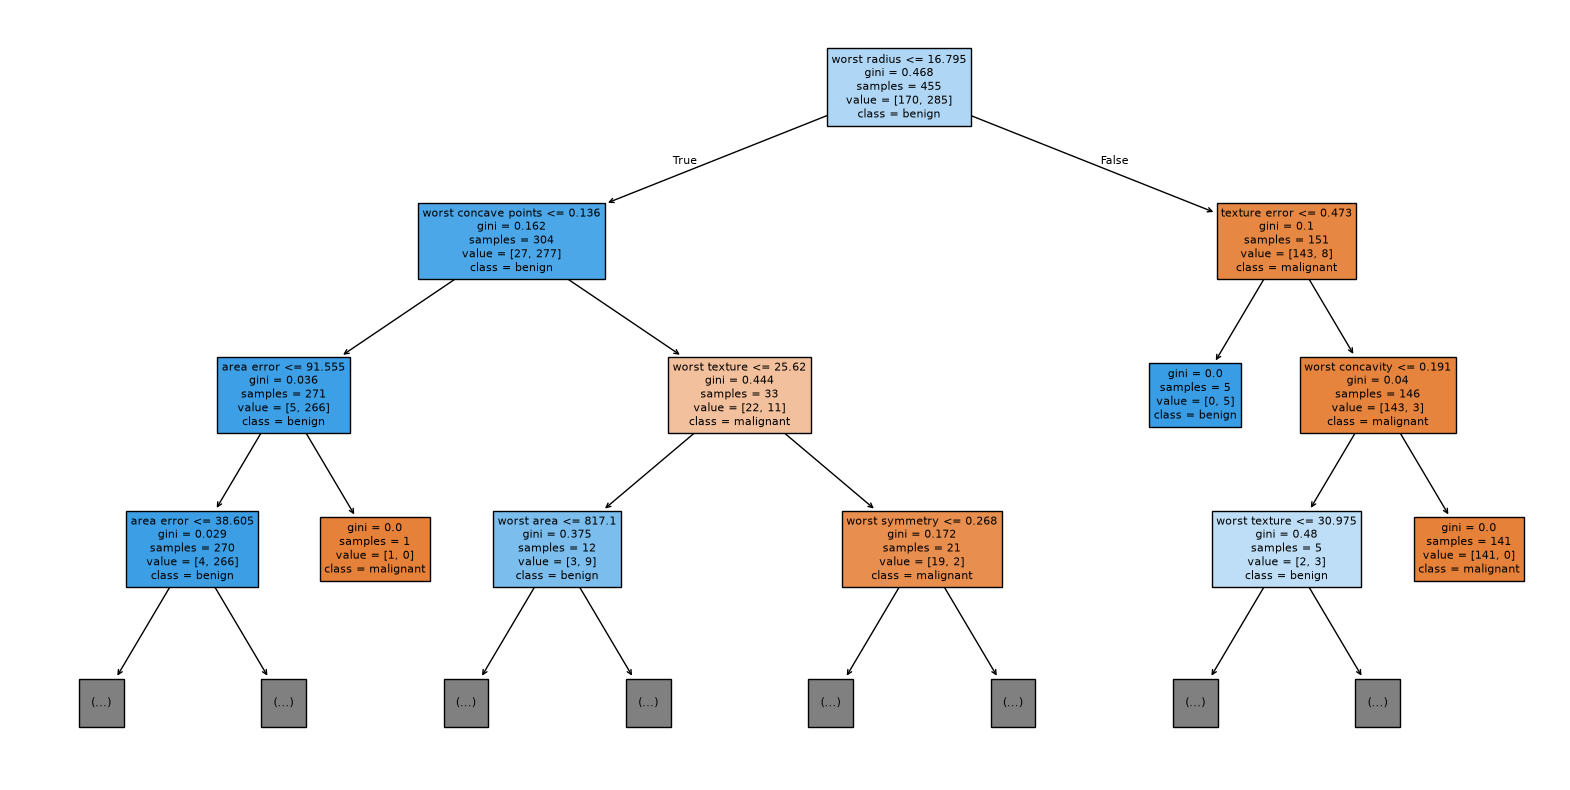

In [88]:
# Let's visualise the tree
# Only for depth 3
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3
)

plt.show()

In [89]:
# Let's understand the overfitting problem
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_accuracy = accuracy_score(
        y_train,
        model.predict(X_train)
    )

    test_accuracy = accuracy_score(
        y_test,
        model.predict(X_test)
    )

    results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "actual_depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

results_df = pd.DataFrame(results)

results_df

,max_depth,train_accuracy,test_accuracy,actual_depth,leaves
0,1.0,0.923077,0.921053,1,2
1,2.0,0.958242,0.894737,2,4
2,3.0,0.975824,0.938596,3,7
3,4.0,0.986813,0.938596,4,11
4,5.0,0.993407,0.921053,5,15
5,6.0,0.997802,0.912281,6,18
6,7.0,1.000000,0.912281,7,19
7,8.0,1.000000,0.912281,7,19
8,10.0,1.000000,0.912281,7,19
9,NaN,1.000000,0.912281,7,19


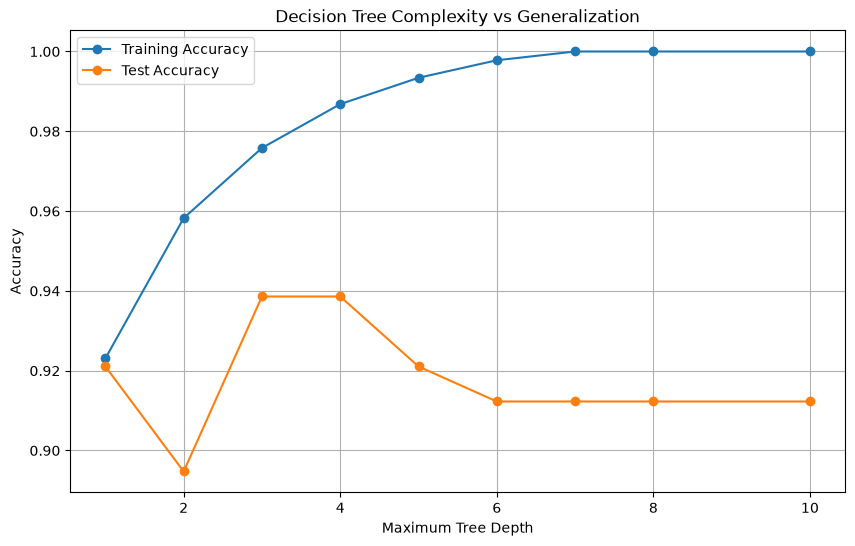

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["max_depth"],
    results_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["max_depth"],
    results_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Complexity vs Generalization")
plt.legend()
plt.grid(True)

plt.show()

Step 13 — Regularizing a Decision Tree

Now let's systematically compare the three controls:

        max_depth
        min_samples_split
        min_samples_leaf

The important thing is not just knowing the parameters. We want to understand what aspect of tree growth each parameter controls.

| Parameter           | Question it asks                                       |
| ------------------- | ------------------------------------------------------ |
| `max_depth`         | **How deep can the tree become?**                      |
| `min_samples_split` | **Does this node have enough observations to split?**  |
| `min_samples_leaf`  | **Will each resulting leaf have enough observations?** |


                 Current Node
                      |
             Can I split this?
                      |
            min_samples_split
                      |
                    YES
                      |
              Candidate split
                      |
          ┌───────────┴───────────┐
          ↓                       ↓
      Left child              Right child
          |                       |
     min_samples_leaf       min_samples_leaf

In [91]:
# Let's Experiment With min_samples_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

values = [2, 5, 10, 20, 30, 50]

results_split = []

for value in values:

    model = DecisionTreeClassifier(
        min_samples_split=value,
        random_state=42
    )

    model.fit(X_train, y_train)

    results_split.append({
        "min_samples_split": value,
        "train_accuracy": accuracy_score(
            y_train,
            model.predict(X_train)
        ),
        "test_accuracy": accuracy_score(
            y_test,
            model.predict(X_test)
        ),
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

split_df = pd.DataFrame(results_split)

split_df

,min_samples_split,train_accuracy,test_accuracy,depth,leaves
0,2,1.000000,0.912281,7,19
1,5,0.995604,0.903509,7,17
2,10,0.989011,0.903509,7,15
3,20,0.978022,0.938596,6,11
4,30,0.975824,0.938596,6,10
5,50,0.962637,0.894737,6,9


In [92]:
# let's try with min_samples_leaf
values = [1, 2, 5, 10, 15, 20]

results_leaf = []

for value in values:

    model = DecisionTreeClassifier(
        min_samples_leaf=value,
        random_state=42
    )

    model.fit(X_train, y_train)

    results_leaf.append({
        "min_samples_leaf": value,
        "train_accuracy": accuracy_score(
            y_train,
            model.predict(X_train)
        ),
        "test_accuracy": accuracy_score(
            y_test,
            model.predict(X_test)
        ),
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves()
    })

leaf_df = pd.DataFrame(results_leaf)

leaf_df

,min_samples_leaf,train_accuracy,test_accuracy,depth,leaves
0,1,1.000000,0.912281,7,19
1,2,0.991209,0.877193,6,16
2,5,0.975824,0.929825,6,13
3,10,0.962637,0.947368,5,10
4,15,0.953846,0.956140,5,9
5,20,0.947253,0.903509,4,7


Now We Need to Discuss Pruning

So far we've been doing pre-pruning.

That means:

We prevent the tree from growing too much in the first place.

Examples:

        max_depth
        min_samples_split
        min_samples_leaf
        max_leaf_nodes
        min_impurity_decrease

Post-Pruning

We can:

        Grow a relatively large tree.
        Examine its branches.
        Remove branches that don't provide enough useful complexity.

This is where Cost-Complexity Pruning comes in.

Cost-Complexity Pruning

The basic idea is to balance:

$$ \text{Tree fit} $$

against:

$$ \text{Tree complexity} $$

The objective can be expressed as:

$$ R_\alpha(T) = R(T)+\alpha|T| $$

where:

		\(T\) = tree
		\(R(T)\) = empirical error/impurity measure
		\(|T|\) = number of terminal nodes
		\(\alpha\) = complexity penalty

The important idea is:

$$ \boxed{ \text{Better fit} + \text{complexity penalty} } $$

As $$\alpha$$ increases:

$$ \alpha \uparrow $$

the penalty for having a large tree increases.

Therefore:

larger α⇒smaller tree
	​


In [93]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

path = dt.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

In [94]:
pd.DataFrame({
    "ccp_alpha": ccp_alphas,
    "impurity": impurities
})

,ccp_alpha,impurity
0,0.000000,0.000000
1,0.002181,0.008723
2,0.002866,0.017322
3,0.002930,0.020252
4,0.003956,0.024208
5,0.004251,0.028459
6,0.005024,0.033483
7,0.005275,0.038757
8,0.005934,0.044691
9,0.007641,0.052332


                    Decision Tree
                         |
              Find best split
                         |
                  Grow recursively
                         |
              ┌──────────┴──────────┐
              ↓                     ↓
        Too simple              Too complex
        Underfitting             Overfitting
              \                     /
               \                   /
                └── Regularization ─┘
                         |
          ┌──────────────┼──────────────┐
          ↓              ↓              ↓
     max_depth    min_samples_split  min_samples_leaf
                         |
                  Pre-pruning
                         |
                  Post-pruning
                         |
                Cost Complexity

And Now We Reach the Key Limitation

There is a deeper problem with Decision Trees.

Even if we carefully regularize them, an individual tree can still have high variance.

If I change the training data slightly:

      Dataset A
         ↓
      Decision Tree A

versus:

      Dataset B
         ↓
      Decision Tree B

the resulting trees can be substantially different.

That instability is a consequence of the recursive splitting process.

And this leads directly to the next question:

What if instead of relying on one Decision Tree, we trained many different Decision Trees and combined their predictions?

That is the central idea of:

Ensemble Learning

And from there:

Decision Tree→Bagging→Random Forest
	​


Why do we need multiple trees?

We have already seen an important property of Decision Trees:

A single decision tree can have high variance.

On our Breast Cancer dataset, the unrestricted tree achieved:

        Training accuracy: 100%
        Test accuracy: 91.23%
        Depth: 7
        Leaves: 19

And when we changed tree complexity, the test performance changed substantially.

The core problem is that a decision tree can be very sensitive to the training data.

Suppose our training dataset contains 100 observations.

We train:

    Dataset
      ↓
    Decision Tree
      ↓
    Tree 1

Now imagine that just 5–10 observations are changed, added, or removed.

We might get:

    Slightly different Dataset
            ↓
      Decision Tree
            ↓
          Tree 2
    
    Tree 1                    Tree 2

    Credit < 650?             Radius < 12?
      /    \                    /     \
    Yes     No                 Yes      No
      |       |                  |        |
    ...     ...                ...      ...

This happens because the tree is making greedy split decisions.

 Ensemble Idea: Instead of relying on one model, train multiple models and combine their predictions.

                Training Data
                     |
       +-------------+-------------+
       |             |             |
       ↓             ↓             ↓
    Tree 1        Tree 2        Tree 3
       |             |             |
       ↓             ↓             ↓
    Class A       Class B       Class A
       \             |             /
        \            |            /
         +-----------+-----------+
                     ↓
               Majority Vote
                     ↓
                  Class A

The hope is that:

Individual trees may make mistakes, but they won't all make the same mistakes. This is the basic intuition behind **Bagging**.

If we simply train the same Decision Tree on exactly the same dataset using the same algorithm:
then, assuming the same deterministic settings, we essentially get the same tree.

That doesn't help much.

So we need to create different training datasets.

And this is where bootstrap sampling comes in.